# Exercise 13:  Resampling methods

This homework assignment is designed to give you practice with bootstrapping and permutation tests.

You will need to download the **unrestricted_trimmed_1_7_2020_10_50_44.csv** file from the *Homework/hcp_data* folder in the class GitHub repository.

This data is a portion of the [Human Connectome Project database](http://www.humanconnectomeproject.org/). It provides measures of cognitive tasks and brain morphology measurements from 1206 participants. The full description of each variable is provided in the **HCP_S1200_DataDictionary_April_20_2018.csv** file in the *Homework/hcp_data* folder in the class GitHub repository.

---
## 1. Loading & Visualizing the Data (1 point)

Use the `setwd` and `read.csv` functions to load data from the **unrestricted_trimmed_1_7_2020_10_50_44.csv** file.

(a) Using the tidyverse tools, create a new dataframe `d1` that only includes the subject ID (`Subject`), gender (`Gender`, self reported at time of data collection), Flanker Task performance (`Flanker_Unadj`), total intracranial volume (`FS_IntraCranial_Vol`), total white matter volume (`FS_Tot_WM_Vol`), and total grey matter volume (`FS_Total_GM_Vol`) variables and remove all _na_ values.

Use the `head` function to look at the first few rows of each data frame.

In [37]:
library(dplyr)
path <- "/Users/kaitlyndalbon/Desktop/Carnegie_Mellon/Courses/85732_Data_Science/DataSciencePsychNeuro/Exercise datasets/hcp_data"
setwd(path)
df <- read.csv("unrestricted_trimmed_1_7_2020_10_50_44.csv")

d1 <- df %>% select(c(Subject, Gender, Flanker_Unadj, FS_IntraCranial_Vol, FS_Tot_WM_Vol, FS_Total_GM_Vol)) %>% na.omit
head(d1)

,Subject,Gender,Flanker_Unadj,FS_IntraCranial_Vol,FS_Tot_WM_Vol,FS_Total_GM_Vol
,<int>,<chr>,<dbl>,<dbl>,<int>,<int>
2,100206,M,130.42,1864518,543134,807245
3,100307,F,112.56,1512540,407292,664124
4,100408,M,121.18,1684117,500417,726206
5,100610,M,126.53,1816044,512946,762308
6,101006,F,101.85,1437868,429449,579632
7,101107,M,107.04,1512727,416995,665024


(b) Plot grey matter volume (x axis) against intracranial volume (y axis) and Gender (point color).


The downloaded binary packages are in
	/var/folders/5_/v0q2657s7b354r1303qrlrxw0000gp/T//RtmpfAB2Jq/downloaded_packages


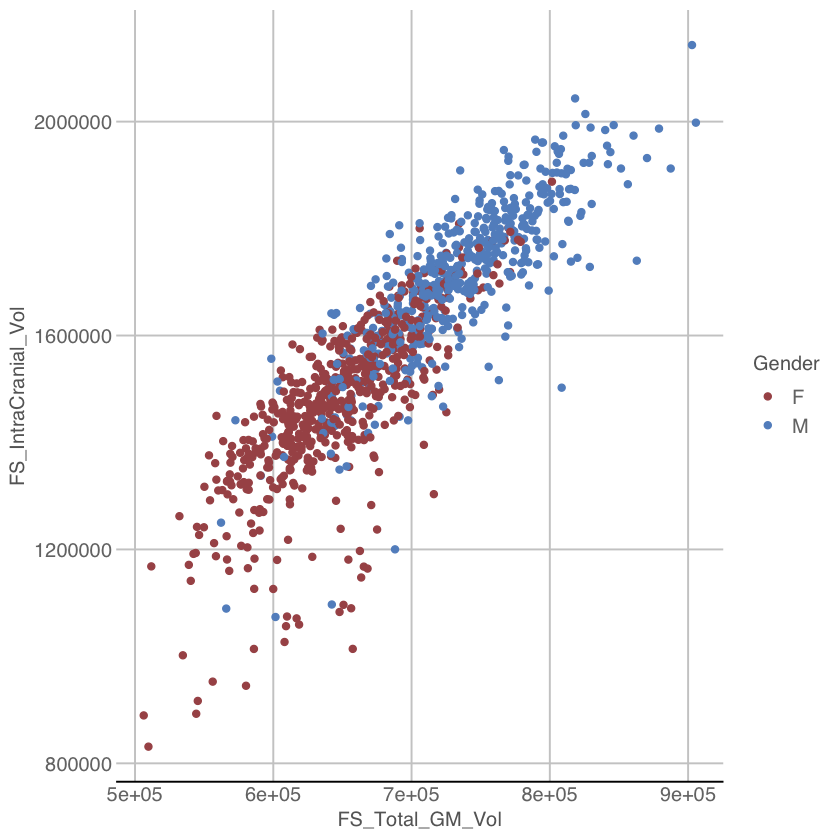

In [38]:
install.packages('ggthemes')
library(ggplot2)
library(ggthemes)

ggplot(d1, aes(x = FS_Total_GM_Vol, y = FS_IntraCranial_Vol, color = Gender)) +
geom_point() +
scale_color_manual(values = c("M" = "#6390C7", "F" = "#a85456")) +
theme_minimal() + theme_gdocs()

What patterns do you observe in the scatter plot?

> I'm noticing an overall positive relationship between intracranial volume and total grey matter volume. Women tend to have lower volume, and men tend to have higher volume. 

---
## 2. Logistic classifier (2 points)

We want to try predicting gender using the neural data you have loaded.

(a) Run a logistic regression model to predict gender from total white matter volume, total grey matter volume, and intracranial volume.

In [39]:
d1 <- d1 %>% mutate(Gender = if_else(Gender == 'F', 1, 0))
mod_1 <- glm(Gender ~ FS_Tot_WM_Vol + FS_Total_GM_Vol + FS_IntraCranial_Vol, 
             data = d1, 
             family = binomial)
summary(mod_1)


Call:
glm(formula = Gender ~ FS_Tot_WM_Vol + FS_Total_GM_Vol + FS_IntraCranial_Vol, 
    family = binomial, data = d1)

Coefficients:
                      Estimate Std. Error z value Pr(>|z|)    
(Intercept)          2.262e+01  1.347e+00  16.787  < 2e-16 ***
FS_Tot_WM_Vol       -2.140e-06  3.059e-06  -0.699    0.484    
FS_Total_GM_Vol     -1.959e-05  3.145e-06  -6.229 4.70e-10 ***
FS_IntraCranial_Vol -5.020e-06  1.177e-06  -4.263 2.01e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1534.13  on 1112  degrees of freedom
Residual deviance:  919.85  on 1109  degrees of freedom
AIC: 927.85

Number of Fisher Scoring iterations: 5


Which factors are significantly associated with gender?

> Intracranial volume and total grey matter volume are significantly associated with gender.

(b) Estimate the prediction accuracy of your model (Note: this is the training set accuracy). Set your prediction threshold to 0.5.

In [49]:
test_df <- data.frame(predicted_accr = predict(mod_1, type = 'response'))
threshold <- 0.50
num_observations = nrow(test_df)

test_df$predicted_binary = rep("0",num_observations)
test_df$predicted_binary[test_df$predicted_accr>threshold]="1" #find the rows that have prob > threshold and cast as '1'
head(test_df)

# confusion matrix
confusion_df = data.frame(test_df$predicted_binary, d1$Gender)
colnames(confusion_df) = c('predicted', 'actual')
table(confusion_df)
accr <- mean(confusion_df$predicted == confusion_df$actual)

# overall accuracy for predictions
print(paste("Accuracy: ", accr))

,predicted_accr,predicted_binary
,<dbl>,<chr>
2,0.02366135,0
3,0.75792878,1
4,0.24316721,0
5,0.07366525,0
6,0.95787337,1
7,0.75063972,1


         actual
predicted   0   1
        0 397  90
        1 110 516

[1] "Accuracy:  0.820305480682839"


What is the prediction accuracy for gender from the full model?

>The prediction accuracy for gender from the full model is about 82%.

---
## 3. Bootstrapped accuracy (3 points)

Use bootstrapping to estimate the confidence interval for your model's prediction accuracy. Plot a histogram of the bootstrapped accuracies, and estimate the confidence interval using the standard deviation of the bootstrap distribution.


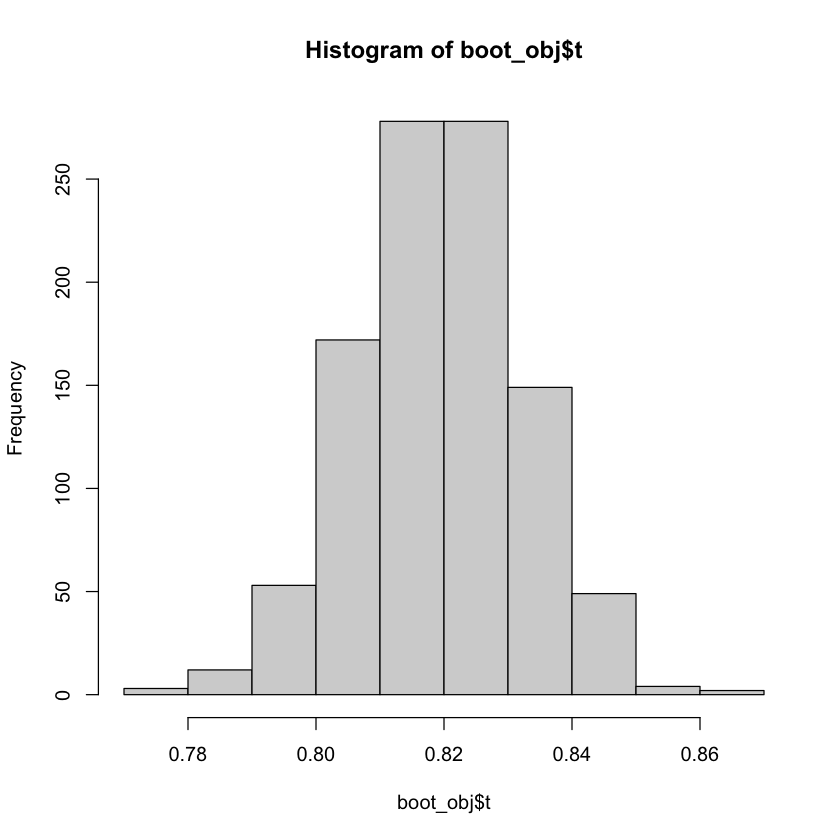

In [50]:
library(boot)

boot.fn <- function(dat, ind){
   df <- dat[ind,]
   mod <- glm(Gender ~ FS_IntraCranial_Vol + FS_Tot_WM_Vol + FS_Total_GM_Vol, data = df, family = binomial)
   test_df$predicted_accr <- predict(mod, type = 'response')
   threshold <- 0.50
   num_observations = nrow(test_df)
   test_df$predicted_binary = rep("0", num_observations)
   test_df$predicted_binary[test_df$predicted_accr>threshold]="1"
   confusion_df = data.frame(test_df$predicted_binary, df$Gender)
   colnames(confusion_df) = c('predicted', 'actual')
   x <- mean(confusion_df$predicted == confusion_df$actual)
   return(x)
}

boot_obj <- boot(d1, boot.fn, R=1000)
#attributes(boot_obj)

hist(boot_obj$t)

# Based on the spread of the bootstrapped model accuracies, the 95% confidence interval seems to be between 0.79 - 0.85.

How robust is the prediction accuracy of the full model?

> I think it is pretty robust. Most of the predicted accuracies cluster around 0.82, as indicated by the highest frequency in the histogram.

---
## 4. Permutation test for grey matter effects (3 points)

Now run a permutation test, with 1000 iterations, to evaluate how much grey matter volume contributes to the prediction accuracy. Compare the prediction accuracy of the full (unpermuted) model with the distribution of accuracies obtained when the grey matter volume variable is permuted, using a histogram (Hint: use the `abline` function to show the original accuracy on the histogram).

[1] "Subject"             "Gender"              "Flanker_Unadj"      
[4] "FS_IntraCranial_Vol" "FS_Tot_WM_Vol"       "FS_Total_GM_Vol"    
[7] "full_mod_accr"

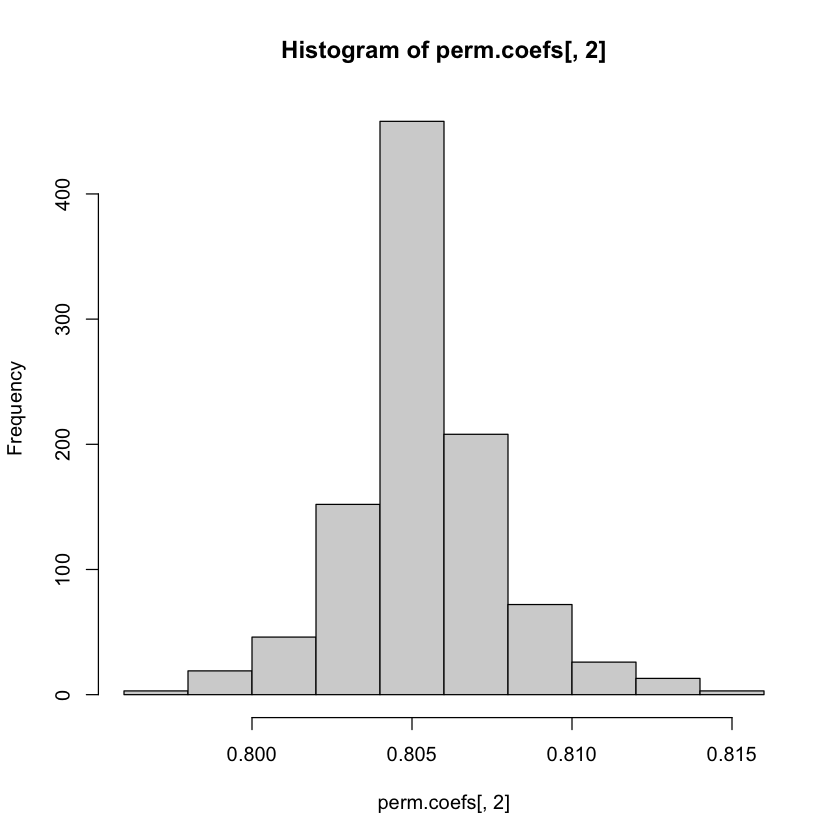

In [48]:
d1_copy <- d1
R <- 1000
perm.coefs <- matrix(NA, nrow=R, ncol=2) #filling with nas at first
d1_copy$full_mod_accr <- predict(mod_1, type = 'response')
colnames(d1_copy)

for (i in 1:R){
  d1_copy$grey <- sample(d1_copy$FS_Total_GM_Vol)
  mod_2 <- glm(Gender~ FS_Tot_WM_Vol + grey + FS_IntraCranial_Vol, data = d1_copy, family = 'binomial')
  d1_copy$predicted_accr <- predict(mod_2, type = 'response')
  threshold <- 0.50
  num_observations = nrow(d1_copy)
  d1_copy$predicted_binary = rep("0", num_observations)
  d1_copy$predicted_binary[d1_copy$predicted_accr>threshold]="1"
  confusion_df = data.frame(d1_copy$predicted_binary, d1_copy$Gender)
  colnames(confusion_df) = c('predicted', 'actual')
  perm.coefs[i,] <- mean(confusion_df$predicted == confusion_df$actual)
}

hist(perm.coefs[,2])
abline(v = accr)

How much does the grey matter volume influence the prediction accuracy of the model?

> Grey matter volume influences and reduces the prediction accuracy, by shifting the prediction accuracy overall toward 0.805 from 0.82, i.e., by 2%.

---
## 5. Reflection (1 point)

Differentiate the bootstrap from a permutation test. Describe each and explain when each is appropriate.

> Permutation tests involve resampling by randomly shuffling the data labels to simulate a null hypothesis in which there is no relationship between variables. I think this allows the researcher to test whether the observed effect could have occurred by chance.

> Bootstrapping, on the other hand, involves sampling with replacement from the observed dataset to estimate the sampling distribution of a statistic. I think it is useful for assessing the variability of an estimate, such as confidence intervals, based on the existing sample.

**DUE:** 11:59pm EST, March 24, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> I did not collaborate with any of my classmates on this assignment.

**GenAI Utilization** Did you utilize any generative AI tools on this assignment? If so, please list the item and the paste respective prompt you used.
> I did not utilize any generative AI tools on this assignment. 